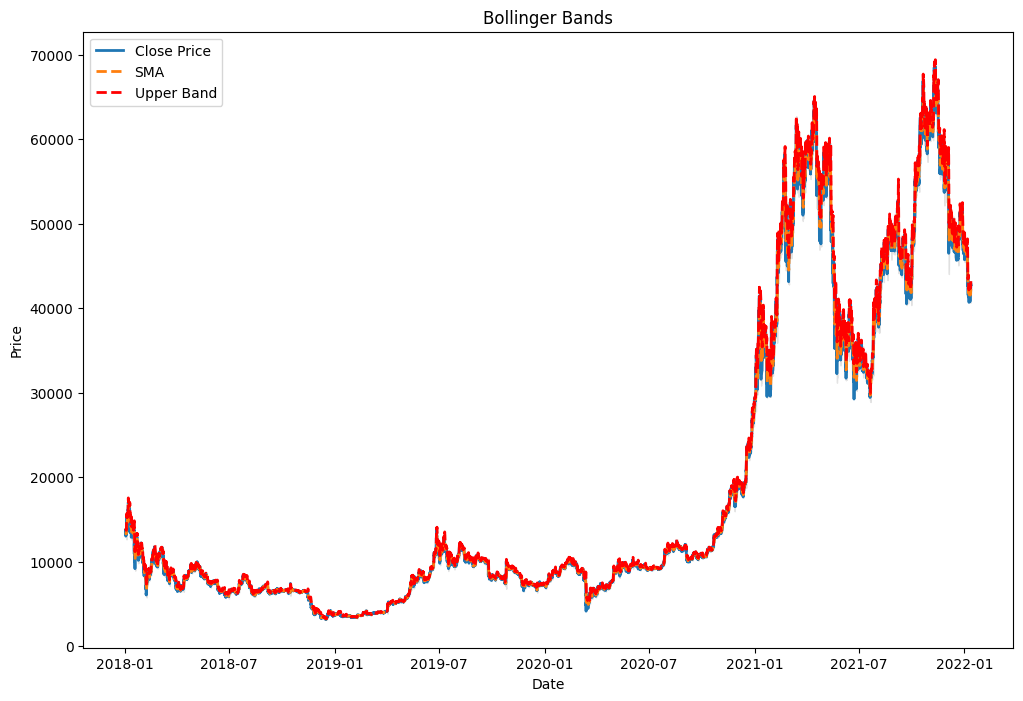

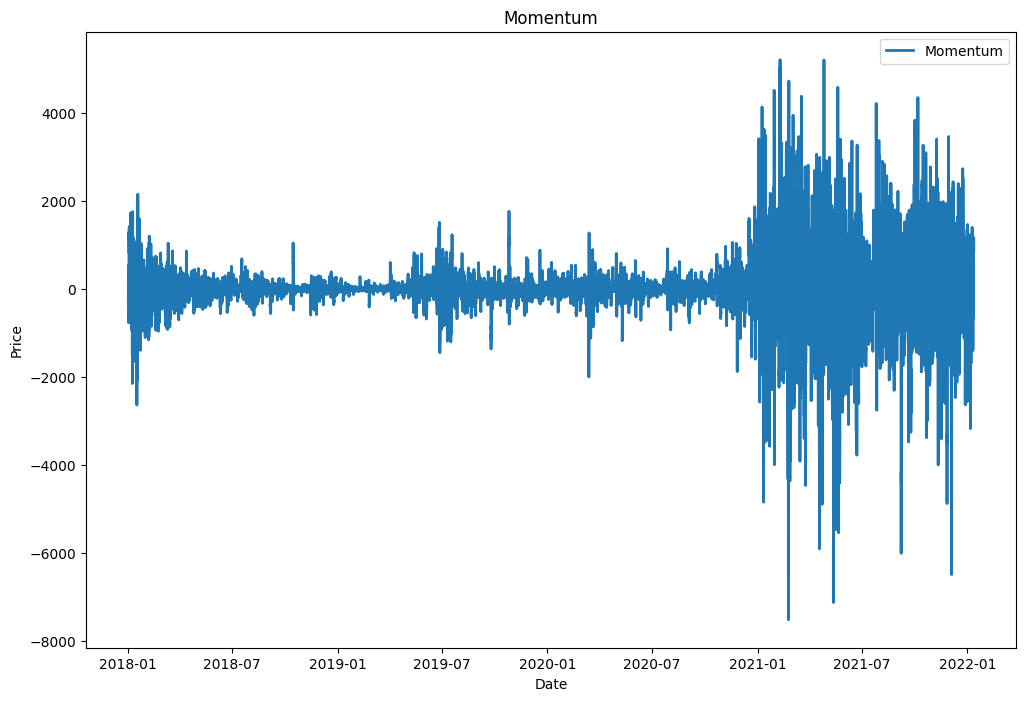

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def calculate_bollinger_bands(data, window, num_std_dev):
    # Calculate the rolling mean and standard deviation
    data['SMA'] = data['close'].rolling(window=window).mean()
    data['Upper'] = data['SMA'] + num_std_dev * data['close'].rolling(window=window).std()
    data['Lower'] = data['SMA'] - num_std_dev * data['close'].rolling(window=window).std()
    return data

def plot_bollinger_bands(data):
    plt.figure(figsize=(12, 8))
    plt.plot(data['close'], label='Close Price', linewidth=2)
    plt.plot(data['SMA'], label='SMA', linestyle='--', linewidth=2)
    plt.plot(data['Upper'], label='Upper Band', linestyle='--', color='red', linewidth=2)
    #plt.plot(data['Lower'], label='Lower Band', linestyle='--', color='green', linewidth=2)
    plt.fill_between(data.index, data['Upper'], data['Lower'], color='gray', alpha=0.2)
    plt.title('Bollinger Bands')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.legend()
    plt.show()

# Load your CSV file
csv_file_path = 'btcusdt_1h.csv'
df = pd.read_csv(csv_file_path, parse_dates=['datetime'], index_col='datetime')

# Set the Bollinger Bands parameters
window_size = 20  # Adjust this parameter based on your strategy
num_std_dev = 2  # Adjust this parameter based on your strategy

# Calculate Bollinger Bands
df = calculate_bollinger_bands(df, window_size, num_std_dev)

# Plot Bollinger Bands
plot_bollinger_bands(df)

#use momentum to detect sudden volatility in the market
def calculate_momentum(data, window):
    data['Momentum'] = data['close'] - data['close'].shift(window)
    return data

# Plot Momentum
def plot_momentum(data):
    plt.figure(figsize=(12, 8))
    plt.plot(data['Momentum'], label='Momentum', linewidth=2)
    plt.title('Momentum')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.legend()
    plt.show()

# Load your CSV file
csv_file_path = 'btcusdt_1h.csv'
df = pd.read_csv(csv_file_path, parse_dates=['datetime'], index_col='datetime')

# Set the Momentum parameter
window_size = 10 # Adjust this parameter based on your strategy

# Calculate Momentum
df = calculate_momentum(df, window_size)

# Plot Momentum
plot_momentum(df)



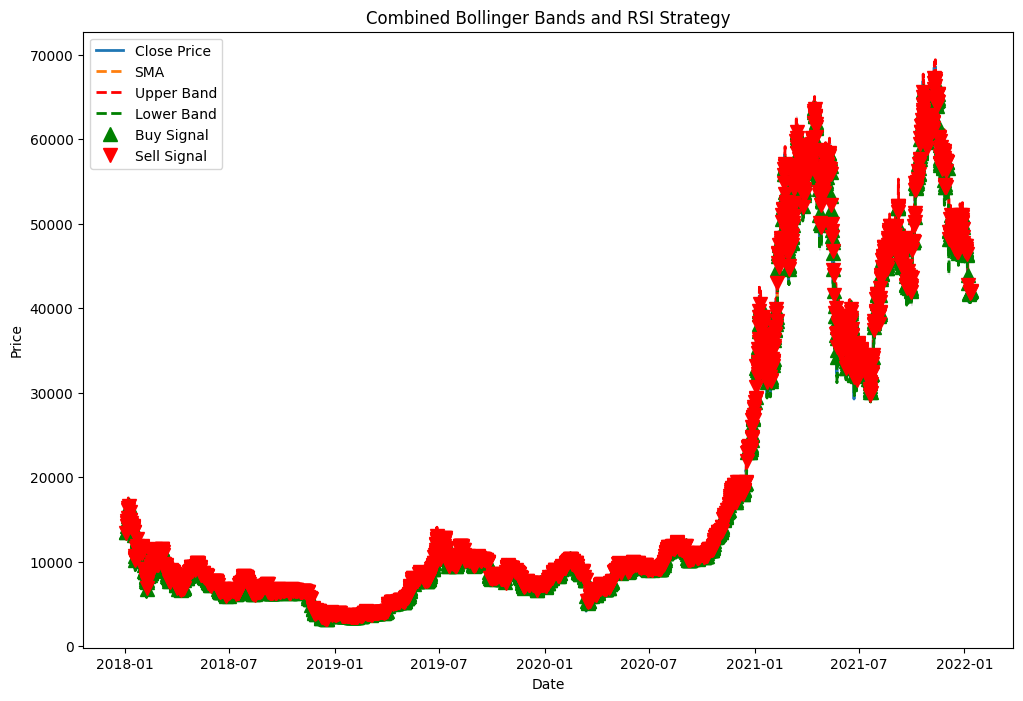

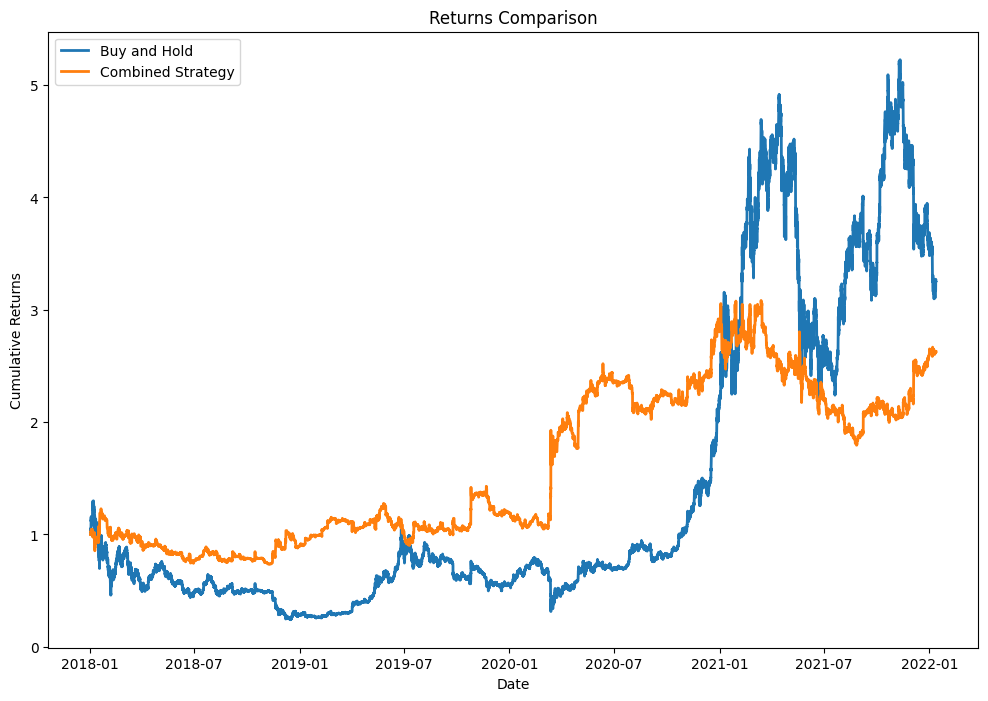

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def calculate_bollinger_bands(data, window, num_std_dev):
    data['SMA'] = data['close'].rolling(window=window).mean()
    data['Upper'] = data['SMA'] + num_std_dev * data['close'].rolling(window=window).std()
    data['Lower'] = data['SMA'] - num_std_dev * data['close'].rolling(window=window).std()
    return data

def calculate_rsi(data, look_back):
    data["Gains"] = np.where(data.close.shift(1) - data.close > 0, data.close.shift(1) - data.close, 0)
    data["Loses"] = np.where(data.close.shift(1) - data.close < 0, data.close - data.close.shift(1), 0)
    data["cGains"] = data["Gains"].rolling(look_back).sum()
    data["cLoses"] = data["Loses"].rolling(look_back).sum()
    data["RSI_Value"] = 100 - (100 / (1 + (data["cGains"] / data["cLoses"])))
    return data

def implement_combined_strategy(data, window, num_std_dev, rsi_look_back):
    data = calculate_bollinger_bands(data, window, num_std_dev)
    data = calculate_rsi(data, rsi_look_back)
    
    # Initialize positions
    data['Position'] = 0  # 0 indicates neutral position
    
    # Generate trading signals based on Bollinger Bands
    data.loc[data['close'] < data['Lower'], 'Position'] = 1  # Go long
    data.loc[data['close'] > data['Upper'], 'Position'] = -1  # Go short
    
    '''
    if data["RSI_Value"].iloc[bar] <= 12.5:                                      # RSI : [0,12.5]    <=> GO SHORT
                data.at[self.data.index[bar],"position"] = -1
            elif data["RSI_Value"].iloc[bar] <= 25:                                      # RSI : [12.5,25]   <=> GO LONG
                data.at[self.data.index[bar],"position"] = 1
            elif data["RSI_Value"].iloc[bar] >= 87.5:                                    # RSI : [87.5,100]  <=> GO LONG
                data.at[self.data.index[bar],"position"] = 1
            elif data["RSI_Value"].iloc[bar] >= 75:                                      # RSI : [75,87.5]   <=> GO SHORT
                data.at[self.data.index[bar],"position"] = -1
            elif data["RSI_Value"].iloc[bar] < 75 and data["RSI_Value"].iloc[bar] > 25:  # RSI : [25,75]     <=> GO NEUTRAL
                data.at[self.data.index[bar],"position"] = 0
    '''

    # Generate trading signals based on RSI
    data.loc[data['RSI_Value'] <= 12.5, 'Position'] = -1  # Go short
    data.loc[data['RSI_Value'] <= 25, 'Position'] = 1  # Go short
    data.loc[data['RSI_Value'] >= 87.5, 'Position'] = 1  # Go long
    data.loc[data['RSI_Value'] >= 75, 'Position'] = -1  # Go short
    

    # Execute trades based on signals
    data['Signal'] = data['Position'].diff()
    
    return data

# Load your CSV file
csv_file_path = 'btcusdt_1h.csv'
df = pd.read_csv(csv_file_path, parse_dates=['datetime'], index_col='datetime')

# Set the strategy parameters
window_size = 20  # Adjust this parameter based on your Bollinger Bands strategy
num_std_dev = 2  # Adjust this parameter based on your Bollinger Bands strategy
rsi_look_back = 14  # Adjust this parameter based on your RSI strategy

# Implement the combined strategy
df = implement_combined_strategy(df, window_size, num_std_dev, rsi_look_back)

# Visualize the strategy
plt.figure(figsize=(12, 8))
plt.plot(df['close'], label='Close Price', linewidth=2)
plt.plot(df['SMA'], label='SMA', linestyle='--', linewidth=2)
plt.plot(df['Upper'], label='Upper Band', linestyle='--', color='red', linewidth=2)
plt.plot(df['Lower'], label='Lower Band', linestyle='--', color='green', linewidth=2)
plt.fill_between(df.index, df['Upper'], df['Lower'], color='gray', alpha=0.2)

# Plot buy (long) signals
plt.plot(df[df['Signal'] == 1].index, df['SMA'][df['Signal'] == 1],
         '^', markersize=10, color='g', label='Buy Signal')

# Plot sell (short) signals
plt.plot(df[df['Signal'] == -1].index, df['SMA'][df['Signal'] == -1],
         'v', markersize=10, color='r', label='Sell Signal')

plt.title('Combined Bollinger Bands and RSI Strategy')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

# Calculate strategy returns
df['buy_n_hold_returns'] = np.log(df['close'] / df['close'].shift(1))
df['strategy_returns'] = df['Position'].shift(1) * df['buy_n_hold_returns']
df.dropna(inplace=True)
df['cum_strategy_returns'] = (1 + df['strategy_returns']).cumprod()

# Plot strategy returns
plt.figure(figsize=(12, 8))
plt.plot(df['buy_n_hold_returns'].cumsum().apply(np.exp), label='Buy and Hold', linewidth=2)
plt.plot(df['cum_strategy_returns'], label='Combined Strategy', linewidth=2)
plt.title('Returns Comparison')
plt.xlabel('Date')
plt.ylabel('Cumulative Returns')
plt.legend()
plt.show()

#convert position to csv    
df.to_csv('position_bollinger.csv', index=True, header=True)



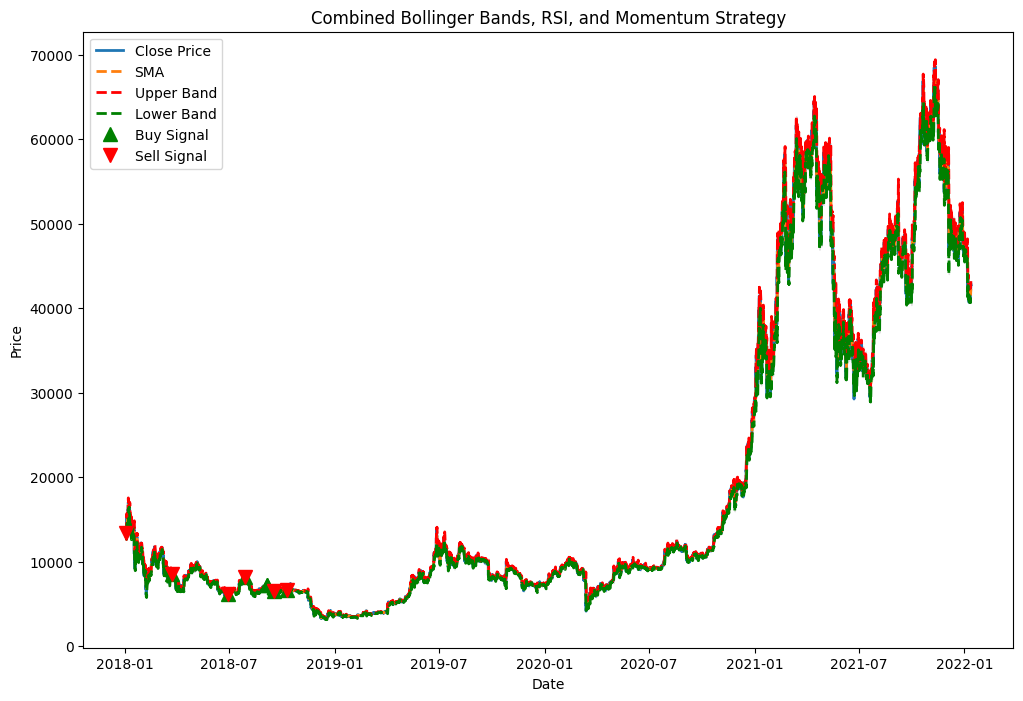

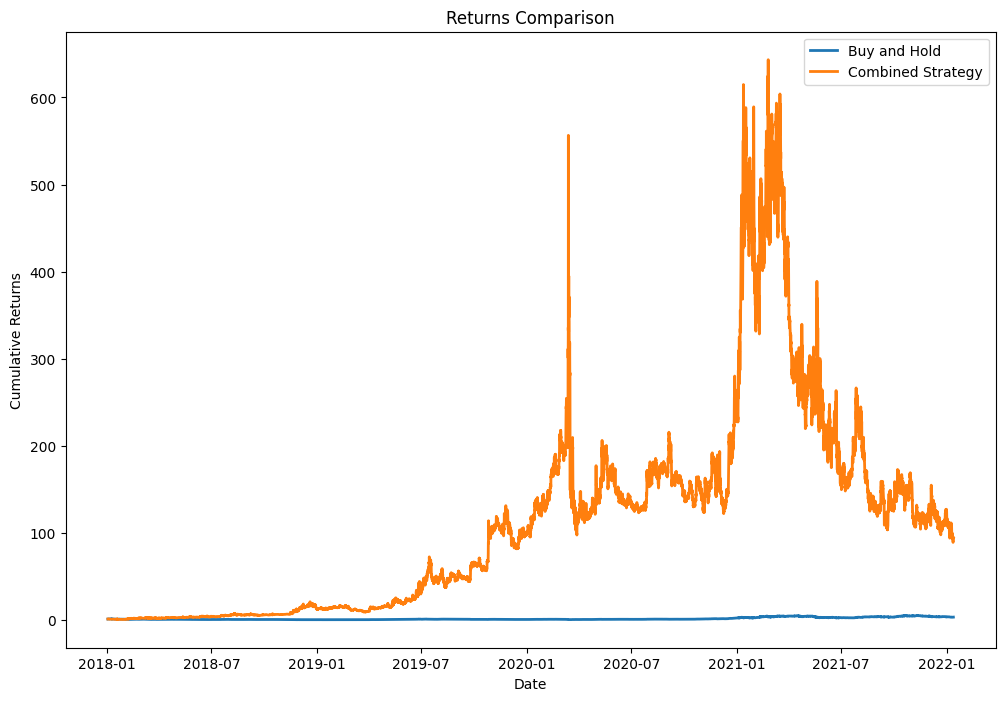

In [36]:
#change strategy when momentum is extremely high or low
def calculate_momentum(data, window):
    data['Momentum'] = data['close'] - data['close'].shift(window)
    return data

def implement_combined_strategy(data, window, num_std_dev, rsi_look_back):
    data = calculate_bollinger_bands(data, window, num_std_dev)
    data = calculate_rsi(data, rsi_look_back)
    data = calculate_momentum(data, window)
    
    # Initialize positions
    data['Position'] = 0  # 0 indicates neutral position
    
    # Generate trading signals based on Bollinger Bands
    data.loc[data['close'] < data['Lower'], 'Position'] = 1  # Go long
    data.loc[data['close'] > data['Upper'], 'Position'] = -1  # Go short
    
    # Generate trading signals based on RSI
    data.loc[data['RSI_Value'] <= 12.5, 'Position'] = -1  # Go short
    data.loc[data['RSI_Value'] <= 25, 'Position'] = 1  # Go short
    data.loc[data['RSI_Value'] >= 87.5, 'Position'] = 1  # Go long
    data.loc[data['RSI_Value'] >= 75, 'Position'] = -1  # Go short
    
    # Generate trading signals based on Momentum
    data.loc[data['Momentum'] > 0, 'Position'] = 1  # Go long
    data.loc[data['Momentum'] < 0, 'Position'] = -1  # Go short

    # Execute trades based on signals, signal can be 1, -1, 0
    # 1 means buy, -1 means sell, 0 means hold

    
    return data

# Load your CSV file
csv_file_path = 'btcusdt_1h.csv'
df = pd.read_csv(csv_file_path, parse_dates=['datetime'], index_col='datetime')

# Set the strategy parameters
window_size = 20  # Adjust this parameter based on your Bollinger Bands strategy
num_std_dev = 2  # Adjust this parameter based on your Bollinger Bands strategy
rsi_look_back = 14  # Adjust this parameter based on your RSI strategy

# Implement the combined strategy
df = implement_combined_strategy(df, window_size, num_std_dev, rsi_look_back)

# Visualize the strategy
plt.figure(figsize=(12, 8))
plt.plot(df['close'], label='Close Price', linewidth=2)
plt.plot(df['SMA'], label='SMA', linestyle='--', linewidth=2)
plt.plot(df['Upper'], label='Upper Band', linestyle='--', color='red', linewidth=2)
plt.plot(df['Lower'], label='Lower Band', linestyle='--', color='green', linewidth=2)
plt.fill_between(df.index, df['Upper'], df['Lower'], color='gray', alpha=0.2)

# Plot buy (long) signals
plt.plot(df[df['Signal'] == 1].index, df['SMA'][df['Signal'] == 1],
         '^', markersize=10, color='g', label='Buy Signal')

# Plot sell (short) signals
plt.plot(df[df['Signal'] == -1].index, df['SMA'][df['Signal'] == -1],
         'v', markersize=10, color='r', label='Sell Signal')

plt.title('Combined Bollinger Bands, RSI, and Momentum Strategy')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()

# Calculate strategy returns
df['buy_n_hold_returns'] = np.log(df['close'] / df['close'].shift(1))
df['strategy_returns'] = df['Position'].shift(1) * df['buy_n_hold_returns']\
    + df['Position'].shift(2) * df['buy_n_hold_returns'].shift(1)

df.dropna(inplace=True)
df['cum_strategy_returns'] = (1 + df['strategy_returns']).cumprod()

# Plot strategy returns
plt.figure(figsize=(12, 8))
plt.plot(df['buy_n_hold_returns'].cumsum().apply(np.exp), label='Buy and Hold', linewidth=2)
plt.plot(df['cum_strategy_returns'], label='Combined Strategy', linewidth=2)
plt.title('Returns Comparison')
plt.xlabel('Date')
plt.ylabel('Cumulative Returns')
plt.legend()
plt.show()

# generate signal csv
df['Signal'].to_csv('signal_combined.csv')




In [33]:
#calculate sharpe ratio and max drawdown and total return
import pandas as pd
import numpy as np

def calculate_sharpe_ratio(data, risk_free_rate):
    excess_returns = data['strategy_returns'] - risk_free_rate
    sharpe_ratio = np.sqrt(len(excess_returns)) * excess_returns.mean() / excess_returns.std()
    return sharpe_ratio

def calculate_max_drawdown(data):
    data['cum_returns'] = (1 + data['strategy_returns']).cumprod()
    data['cum_roll_max'] = data['cum_returns'].cummax()
    data['drawdown'] = data['cum_roll_max'] - data['cum_returns']
    data['drawdown_pct'] = data['drawdown'] / data['cum_roll_max']
    max_drawdown = data['drawdown_pct'].max()
    return max_drawdown

def calculate_cumulative_returns(data):
    data['cum_returns'] = (1 + data['strategy_returns']).cumprod()
    return data

def calculate_total_return(data):
    total_return = data['strategy_returns'].sum()
    return total_return

print('Sharpe Ratio:', calculate_sharpe_ratio(df, 0.01))
print('Max Drawdown:', calculate_max_drawdown(df))
print('Total Return:', calculate_total_return(df))
print('Cumulative Returns:' , calculate_cumulative_returns(df))

Sharpe Ratio: -150.3270437908694
Max Drawdown: 0.8615734558579272
Total Return: 7.166702154916094
Cumulative Returns:                          open      high       low     close       volume  \
datetime                                                                   
2018-01-02 01:30:00  13222.03  13472.00  13222.03  13399.24   412.026868   
2018-01-02 02:30:00  13399.23  13580.67  13380.82  13481.01   326.923135   
2018-01-02 03:30:00  13494.99  13599.70  13450.96  13452.00   303.301385   
2018-01-02 04:30:00  13455.24  13500.00  13355.01  13380.00   345.218495   
2018-01-02 05:30:00  13382.16  13850.00  13382.16  13750.01   466.596114   
...                       ...       ...       ...       ...          ...   
2022-01-12 01:30:00  42972.04  43095.26  42692.19  42800.38  1219.601780   
2022-01-12 02:30:00  42797.62  42823.69  42643.74  42659.20   702.103800   
2022-01-12 03:30:00  42664.71  42776.14  42597.41  42713.13   561.859930   
2022-01-12 04:30:00  42713.12  42886.28  42633